In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

In [2]:
gdf = gpd.read_file("../data/raw/shapes/AL_municipios/AL_Municipios_2023.shp")

munic = pd.read_csv("../data/processed/municipios_alagoas.csv")

al = pd.read_parquet("../data/processed/escolas_alagoas.parquet")

munic_codigo = al.groupby(["NO_MUNICIPIO", "CO_MUNICIPIO"]).size().reset_index()[["NO_MUNICIPIO","CO_MUNICIPIO"]]
munic = munic.merge(munic_codigo, on="NO_MUNICIPIO", how="left")
munic["CO_MUNICIPIO"] = munic["CO_MUNICIPIO"].astype(str).str[:7]
gdf["CD_MUN"] = gdf["CD_MUN"].astype(str).str[:7]

geo = gdf.merge(munic, left_on="CD_MUN", right_on="CO_MUNICIPIO", how="left")

print(f"Municípios no mapa: {len(geo)}")
print(f"Com dados: {geo['perc_negros'].notna().sum()}")
geo.head(3)

Municípios no mapa: 102
Com dados: 102


,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,CD_REGIAO,NM_REGIAO,CD_CONCURB,NM_CONCURB,AREA_KM2,geometry,NO_MUNICIPIO,perc_negros,perc_internet,n_escolas,score_desigualdade,CO_MUNICIPIO
0,2700102,Água Branca,270009,Delmiro Gouveia,2702,Arapiraca,27,Alagoas,2,Nordeste,None,None,473.845,"POLYGON ((-37.93395 -9.37265, -37.97968 -9.347...",Água Branca,38.207987,0.923077,13,-54.099705,2700102
1,2700201,Anadia,270004,São Miguel dos Campos,2701,Maceió,27,Alagoas,2,Nordeste,None,None,186.134,"POLYGON ((-36.24734 -9.70618, -36.24777 -9.707...",Anadia,79.941683,1.000000,18,-20.058317,2700201
2,2700300,Arapiraca,270007,Arapiraca,2702,Arapiraca,27,Alagoas,2,Nordeste,2700300,Arapiraca,345.655,"POLYGON ((-36.66698 -9.81639, -36.66702 -9.816...",Arapiraca,54.490781,1.000000,154,-45.509219,2700300


Porcentagem de alunos negros+pardos por município

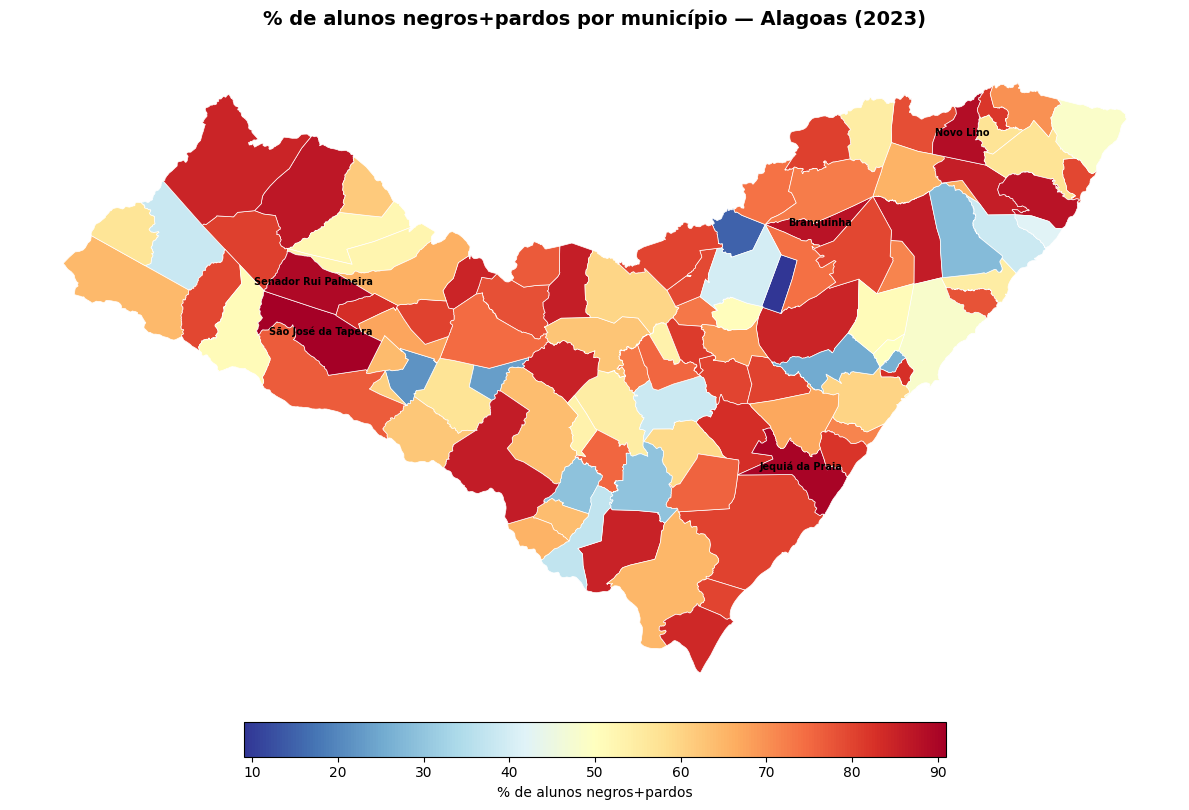

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

geo.plot(
    column="perc_negros",
    ax=ax,
    cmap="RdYlBu_r",
    legend=True,
    missing_kwds={"color": "#eeeeee", "label": "Sem dados"},
    legend_kwds={
        "label": "% de alunos negros+pardos",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.02
    },
    edgecolor="white",
    linewidth=0.5
)

#destaquei os 5 municípios com maior desigualdade. pq? pq eu quis :)
top5 = geo.nlargest(5, "perc_negros")
for _, row in top5.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row["NM_MUN"],
        xy=(centroid.x, centroid.y),
        fontsize=7,
        ha="center",
        color="black",
        fontweight="bold"
    )

ax.set_title("% de alunos negros+pardos por município — Alagoas (2023)",
             fontsize=14, pad=20, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("../outputs/08_mapa_negros_municipios.png", dpi=150, bbox_inches="tight")
plt.show()

acesso a internet por município

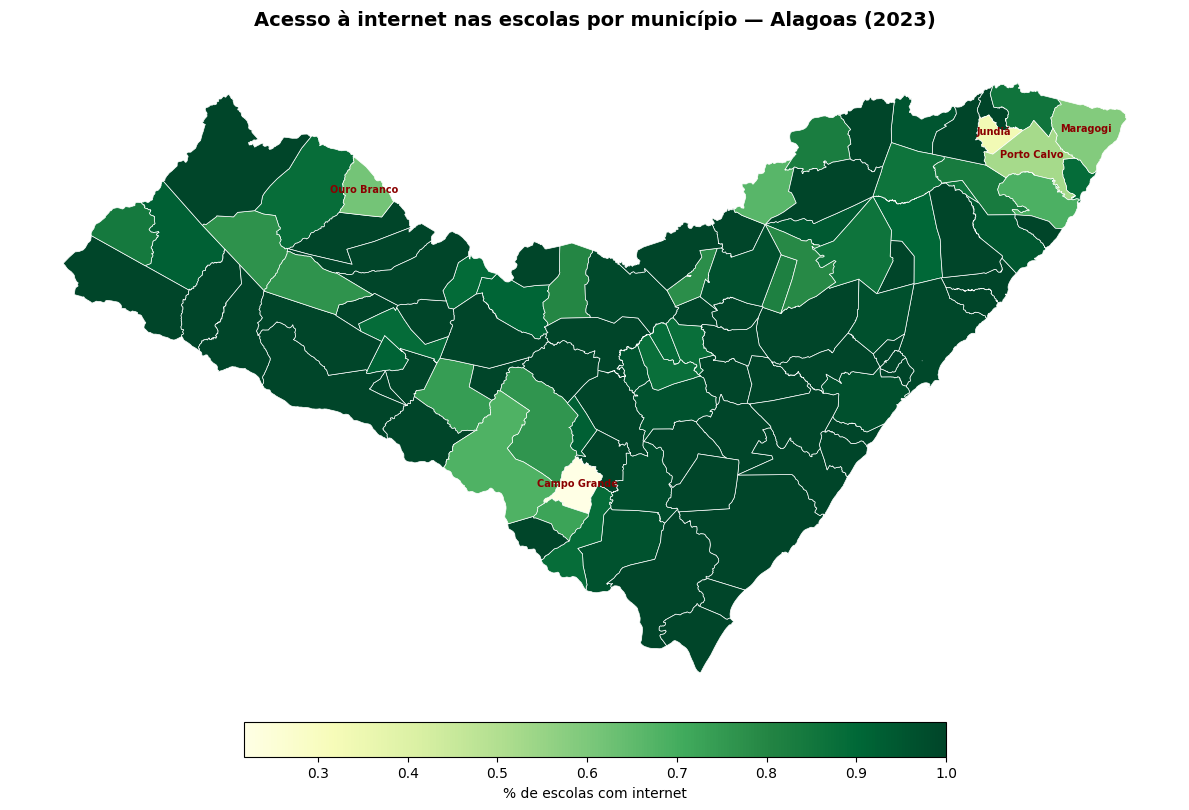

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

geo.plot(
    column="perc_internet",
    ax=ax,
    cmap="YlGn",
    legend=True,
    missing_kwds={"color": "#eeeeee", "label": "Sem dados"},
    legend_kwds={
        "label": "% de escolas com internet",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.02
    },
    edgecolor="white",
    linewidth=0.5
)



#destaquei os 5 municípios com menor acesso. pq? acho q vc já sabe
bot5 = geo.nsmallest(5, "perc_internet").dropna(subset=["perc_internet"])
for _, row in bot5.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row["NM_MUN"],
        xy=(centroid.x, centroid.y),
        fontsize=7,
        ha="center",
        color="darkred",
        fontweight="bold"
    )

ax.set_title("Acesso à internet nas escolas por município — Alagoas (2023)",
             fontsize=14, pad=20, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("../outputs/09_mapa_internet_municipios.png", dpi=150, bbox_inches="tight")
plt.show()

Destaque de desigualdade por cores

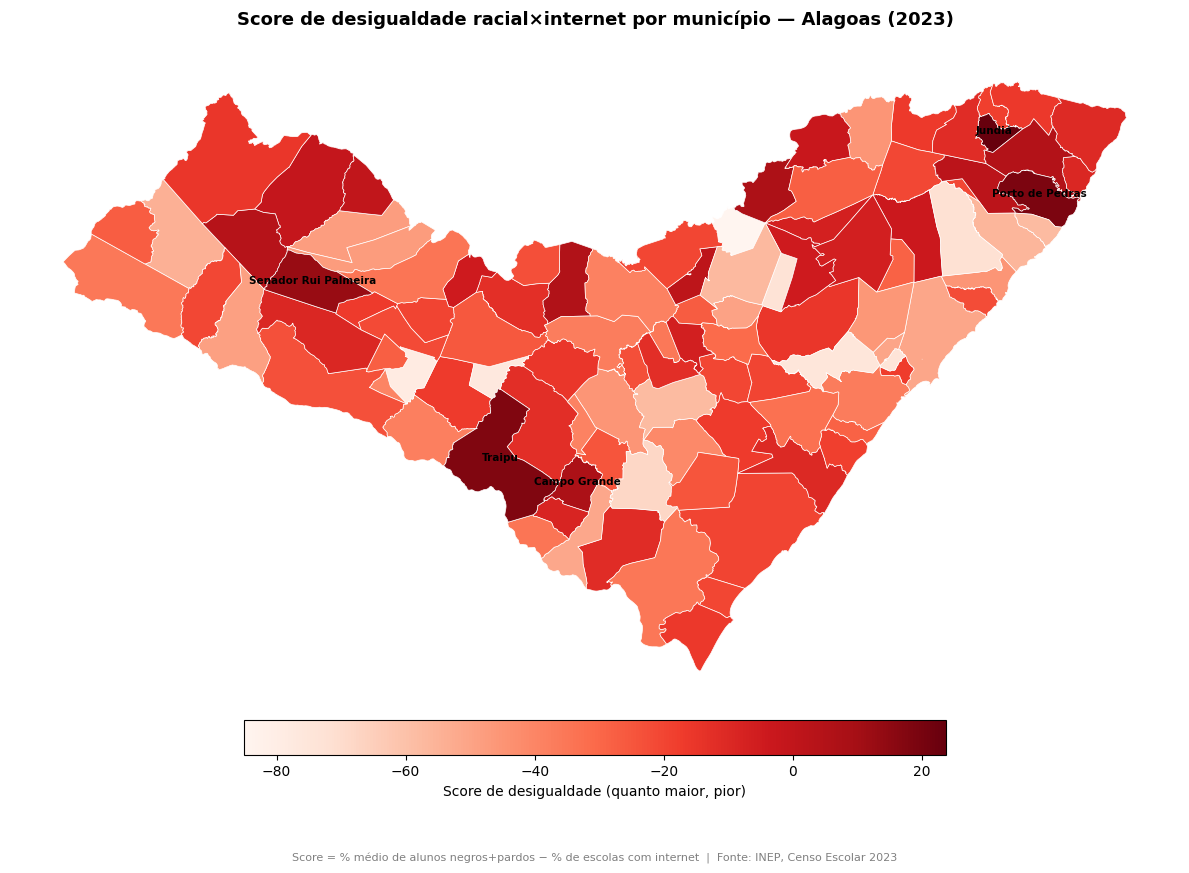

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

geo.plot(
    column="score_desigualdade",
    ax=ax,
    cmap="Reds",
    legend=True,
    missing_kwds={"color": "#eeeeee", "label": "Sem dados"},
    legend_kwds={
        "label": "Score de desigualdade (quanto maior, pior)",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.02
    },
    edgecolor="white",
    linewidth=0.5
)

#destaque dos 5 piores, o resto você já sabe
top5_desi = geo.nlargest(5, "score_desigualdade").dropna(subset=["score_desigualdade"])
for _, row in top5_desi.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row["NM_MUN"],
        xy=(centroid.x, centroid.y),
        fontsize=7.5,
        ha="center",
        color="black",
        fontweight="bold"
    )

ax.set_title("Score de desigualdade racial×internet por município — Alagoas (2023)",
             fontsize=13, pad=20, fontweight="bold")
ax.axis("off")

fig.text(0.5, 0.02,
         "Score = % médio de alunos negros+pardos − % de escolas com internet  |  Fonte: INEP, Censo Escolar 2023",
         ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("../outputs/10_mapa_desigualdade.png", dpi=150, bbox_inches="tight")
plt.show()